# Topic 

In [3]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("all_streaming_titles.csv")

# -----------------------------
# 1. Define topic keywords
# -----------------------------
topics = {
    "lgbtq": ["gay", "lesbian", "lgbt", "trans", "queer"],
    "politics": ["politics", "president", "government", "election", "policy"],
    "climate": ["climate", "environment", "global warming", "pollution"],
    "war": ["war", "battle", "army", "soldier", "military"],
    "family": ["family", "mother", "father", "children", "home"],
    "crime": ["crime", "murder", "police", "detective", "investigation"],
    "romance": ["love", "romance", "relationship", "couple"],
    "technology": ["technology", "ai", "robot", "future", "cyber"]
}

# -----------------------------
# 2. Clean overview text
# -----------------------------
df["overview_clean"] = df["overview"].fillna("").str.lower()

# -----------------------------
# 3. Create topic columns
# -----------------------------
for topic, keywords in topics.items():
    df[f"topic_{topic}"] = df["overview_clean"].apply(
        lambda x: int(any(keyword in x for keyword in keywords))
    )

topic_cols = [col for col in df.columns if col.startswith("topic_")]

df["topic_diversity_score"] = df[topic_cols].sum(axis=1)  

print(df[[col for col in df.columns if "topic_" in col]].head())

   topic_lgbtq  topic_politics  topic_climate  topic_war  topic_family  \
0            0               0              0          0             0   
1            0               0              0          1             0   
2            0               0              0          0             0   
3            0               0              0          1             1   
4            0               0              0          1             0   

   topic_crime  topic_romance  topic_technology  topic_diversity_score  
0            0              0                 0                      0  
1            0              0                 1                      2  
2            0              0                 0                      0  
3            0              0                 1                      3  
4            0              0                 0                      1  


# K-Means Clustering (Main Model)

Select Features

In [4]:
from sklearn.preprocessing import StandardScaler

features = [
    "popularity",
    "vote_count",
    "vote_average",
    "business_value_score",
    "topic_diversity_score"
]

X = df[features].fillna(0)

Scale Data

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Find optimal K (Elbow method)

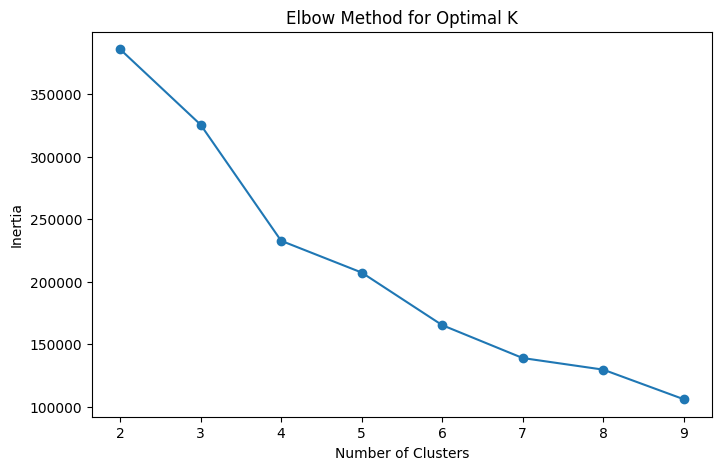

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

between 4 and 5 

Train Final Model

In [7]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

Interpret clusters 

In [8]:
cluster_summary = df.groupby("cluster")[features].mean()
print(cluster_summary)

         popularity   vote_count  vote_average  business_value_score  \
cluster                                                                
0          1.473153    91.817879      6.960850             22.955252   
1          1.263259    72.678645      6.964998             22.921225   
2         44.163055  7798.919924      7.387593             33.457834   
3          7.446442    13.848613      2.247757             13.313882   

         topic_diversity_score  
cluster                         
0                     2.380114  
1                     0.640472  
2                     1.121068  
3                     1.029619  


label Clusters

In [9]:
def label_cluster(row):
    if row["business_value_score"] > 70:
        return "High Value Content"
    elif row["popularity"] > df["popularity"].median():
        return "High Visibility"
    elif row["vote_average"] > 7:
        return "Quality Niche"
    else:
        return "Low Performance"

df["cluster_label"] = df.apply(label_cluster, axis=1)

# Visualize Clusters

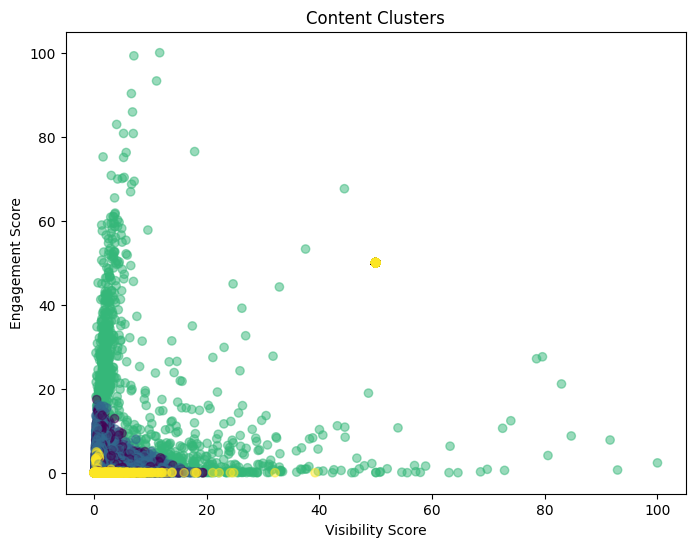

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df["visibility_score"],
    df["engagement_score"],
    c=df["cluster"],
    alpha=0.5
)

plt.title("Content Clusters")
plt.xlabel("Visibility Score")
plt.ylabel("Engagement Score")
plt.show()

# Marketing Insights

In [11]:
cluster_insights = df.groupby("cluster_label").agg({
    "title": "count",
    "business_value_score": "mean",
    "visibility_score": "mean",
    "engagement_score": "mean"
}).rename(columns={"title": "count"})

print(cluster_insights)

                 count  business_value_score  visibility_score  \
cluster_label                                                    
High Visibility  13725             23.071785           2.96537   
Low Performance  78657             22.736848          50.00000   
Quality Niche     3818             23.948583          50.00000   

                 engagement_score  
cluster_label                      
High Visibility          2.877855  
Low Performance         50.000000  
Quality Niche           50.000000  


# Save Final Data Set

In [12]:
df.to_csv("final_streaming_dataset.csv", index=False)


Now I have:

✅ Quantitative features
popularity
vote_count
vote_average
business_value_score

✅ Qualitative features (LLM-style)
topic_lgbtq
topic_politics
topic_climate
etc.

✅ Behavioral features
topic_diversity_score

✅ ML output
cluster
cluster_label


SABINA COMMENT: What are we doing? Why are we doing it? What are those numbers saying?